# BioHub Baseline submission notebook (v1)

Uses simple baseline algorithm: Cell detections per time frame -> Linking them to successive timeframe detections (mainting division heuristics as well)

2 step solution, pretty basic. Perfect for an initial baseline. 

### 1. Detection - 

1. Uses a simple thresholding (Otsu for our case) on gaussian smoothed volumes (Z, Y, X) at time (t).
2. Locate peaks in the distribution (binary thresholded mask), scale them to the volume coordinates (If preprocessing used pooling).
3. Calculate the score for each point using a small crop of volume around it and removing the bg intensities from the crop. Generally mean does ok. Lets call this crop "local_reference_crop" for the point.
[OPTIONAL]: _refine the peaks by reshifting the points to the center of mass calculated for the "local_reference_crop", configurable.
4. Physical NMS, limiting by keeping only top k predictions. 

Pass the outputs of the predictions as coordinates for linking and graph building

### 2. Linking - 

1. Needs three primary inputs - {Detections for Frame t (DetFrame(t)), Detections for Frame t-1 (DetFrame(t-1)), Velocity at t-1 (VelFrame(t-1)) [which is again calculated from t-2 -> t-1]}
2. Calculates the predicted trajectory of DetFrame(t-1):- store in pred.
3. Get the distance of DetFrame(t) from preds. 
4. Match DetFrame(t-1) pred to DetFrame(t) using this metric. (Think of it as using velocity as a prior to aid matching)

5. Check for divisions as well 

6. Loop for unmatched detections in DetFrame(t) 

1. get the closest parent detection from it
2. Check if the parent already has a child (Its match for t)
3. If yes, get the distance of the sisters (all children of that parent) from this candidate
4. keep the closest sister, check if this distance is lesser than an acceptable threshold (Configurable)
5. append this edge in extras - list(tuple) -- [(i,j)]

6. Return output of linking and division check together as links -- (list[tuple])

## Config

In [39]:
from dataclasses import dataclass, field
import numpy as np

SCALE_ZYX = np.array([1.625, 0.40625, 0.40625])

@dataclass
class config:

    gaussian_sigma: float = 1.0
    ds_factor_xy: int = 4
    thresh_rel: float = 0.32
    use_otsu: bool = True
    min_peak_dist: float = 2
    border_z: int = 0
    refine_rz: int = 2
    refine_ryx: int = 5
    nms_radius_um: float = 7.0
    scale: np.ndarray = field(default_factory=lambda: SCALE_ZYX.copy())
    max_nodes_per_frame: int = 0
    use_motion: bool = False
    gate: float = 6.0
    max_link_distance_um: float = 10.0
    prune_isolated: bool = True
    keep_strong_isolated_q: float = 0.0
    detect_divisions: bool = True
    div_min_count_gain: int = 1
    div_parent_dist_um: float = 9.0
    div_sister_dist_um: float = 9.0

## Detection

### Utils

In [40]:
# Load volume .zarr, annotation .geff functions

import numpy as np
import pandas as pd
import zarr
from pathlib import Path

TRAIN_PATH = Path("/Users/ishan/Desktop/biohub_kaggle/data/train")
_ZC = {} # Cache 

def load_volume(vol_id: str):

    "Open the multiscale array '0', shape (T, Z, Y, X), cached by path."

    key = str(TRAIN_PATH / (vol_id + ".zarr"))
    if key not in _ZC:
        _ZC[key] = zarr.open(key, mode="r")["0"]
    return _ZC[key]

def read_geff(vol_id: str):

    "Read annotations from the .geff directory -> (nodes, edges) DataFrames."

    from geff import read as geff_read

    g = geff_read(str(TRAIN_PATH / (vol_id + ".geff")), backend="networkx")[0]
    nodes = pd.DataFrame([{"node_id": int(i), "t": int(round(float(d["t"]))),
                           "z": float(d["z"]), "y": float(d["y"]), "x": float(d["x"])}
                          for i, d in g.nodes(data=True)])
    nodes = nodes.sort_values(["t", "node_id"]).reset_index(drop=True)
    edges = pd.DataFrame([{"source_id": int(u), "target_id": int(v)} for u, v in g.edges()],
                         columns=["source_id", "target_id"])
    return nodes, edges

def load_sample(vol_id: str):
    "Convenience loader -> (zarr_array (T,Z,Y,X), nodes, edges)."
    return load_volume(vol_id), *read_geff(vol_id)

Detection pipeline - 

1. There is a heavy anisotropy noticed in the volumes, (z~1.6 while x, y ~ 0.4) spacing.
2. One way to address this is to pool only via x and y axis by a factor of 4, or rescale accordingly. We ll be using pooling for the initial baseline.
3. Once pooled -> Pass it via a gaussian filter to intensify centroid peaks. 
4. Record the peaks, apply nms, limit to top-k predictions and optinally, _refine. 
5. wrap it detect() function

In [41]:
from scipy.ndimage import gaussian_filter 
from typing import List
from skimage.filters import threshold_otsu
from skimage.feature import peak_local_max
from scipy.spatial import cKDTree

def _mean_xy(
    volume: np.ndarray,
    f: int
):
    Z, Y, X = volume.shape; Y2, X2 = (Y//f)*f, (X//f)*f
    crop = volume[:, :Y2, :X2].astype(np.float32, copy=False)
    return crop.reshape(Z, Y2//f, f, X2//f, f).mean(axis=(2, 4))

def _threshold(
    smooth,
    cfg,
):
    
    bg = float(np.median(smooth)); hi = float(np.percentile(smooth, 99.9)) # BG - median, hi - 99.9% zones
    rel = bg + cfg.thresh_rel * max(hi - bg, 1e-6)

    if cfg.use_otsu:

        try: return max(float(threshold_otsu(smooth)), rel)
        except Exception: pass

    return max(float(np.percentile(smooth, 96.0)), rel)

def _peaks(
    smooth,
    threshold,
    d,
):
    
    return peak_local_max(
        smooth,
        min_distance=d,
        threshold_abs=threshold, 
        exclude_border=False
    ).astype(np.int32)

def _refine(
    vol, 
    zyx, 
    cfg
):

    """
    Refines detections by shifting the detected centers towards a center of mass 
    calculated from its local_reference_crop. 
    """

    Z, Y, X = vol.shape; z, y, x = (int(round(v)) for v in zyx)
    z0,z1 = max(0,z-cfg.refine_rz), min(Z,z+cfg.refine_rz+1)
    y0,y1 = max(0,y-cfg.refine_ryx), min(Y,y+cfg.refine_ryx+1)
    x0,x1 = max(0,x-cfg.refine_ryx), min(X,x+cfg.refine_ryx+1)
    crop = vol[z0:z1, y0:y1, x0:x1].astype(np.float32); bg = float(crop.min())
    w = np.clip(crop-bg, 0, None); s = float(w.sum())

    if s <= 0: return np.array([z,y,x], float), 0.0
    zz,yy,xx = np.mgrid[z0:z1, y0:y1, x0:x1]

    return np.array([(zz*w).sum(),(yy*w).sum(),(xx*w).sum()])/s, float(crop.max()-bg)

def _physical_nms(
    coords, 
    scores, 
    radius_um, 
    scale
):
    
    if len(coords) <= 1: return coords, scores

    pts = coords*scale[None,:]; order = np.argsort(-scores)
    tree = cKDTree(pts); killed = np.zeros(len(coords), bool); keep = []

    for i in order:
        if killed[i]: continue
        keep.append(int(i)); killed[tree.query_ball_point(pts[i], r=radius_um)] = True

    keep = np.array(keep); return coords[keep], scores[keep]

def detect(
    volume,
    cfg,
):
    
    f = cfg.ds_factor_xy
    pooled = _mean_xy(volume, f) if f > 1 else volume.astype(np.float32)
    sm = gaussian_filter(pooled, cfg.gaussian_sigma) if cfg.gaussian_sigma > 0.0 else pooled
    pk = _peaks(sm, _threshold(sm, cfg), cfg.min_peak_dist)

    if len(pk) == 0: return np.zeros((0,3)), np.zeros(0)

    full = pk.astype(float)
    full[:,1] = full[:,1]*f + (f-1)/2; full[:,2] = full[:,2]*f + (f-1)/2 # Expand x and y coordinates by f

    Z = volume.shape[0]; 
    coords, scores = [], []
    
    for p in full:
        if p[0] < cfg.border_z or p[0] > Z-1-cfg.border_z: continue
        c, s = _refine(volume, p, cfg); 
        coords.append(c); scores.append(s)
        
    if not coords: return np.zeros((0,3)), np.zeros(0)
        
    coords = np.array(coords); scores = np.array(scores)
    no_nms_coords, no_nms_scores = coords, scores

    coords, scores = _physical_nms(coords, scores, cfg.nms_radius_um, cfg.scale)
    
    if cfg.max_nodes_per_frame and len(coords) > cfg.max_nodes_per_frame:
        k = np.argsort(-scores)[:cfg.max_nodes_per_frame]; coords, scores = coords[k], scores[k]
        
    return coords, scores

In [ ]:
# Load a vol and run sanity test
cfg = config()

vol = load_volume(vol_id="6bba_2540cd90")
vol_t = vol[1]

# Get detections - 
coords, scores= detect(vol_t, cfg)

Text(0.5, 1.0, 'With NMS')

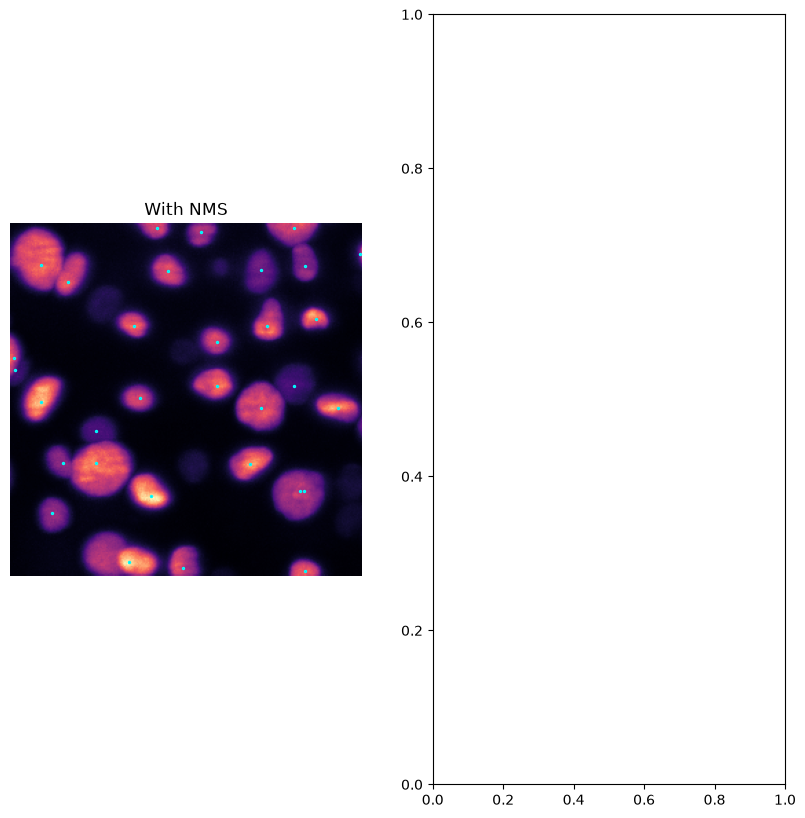

In [44]:
# Plot the z mip of volume and see the detections
import matplotlib.pyplot as plt

mip_vol = vol_t.max(0)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,10))

ax[0].imshow(mip_vol, cmap="magma")
ax[0].scatter(coords[:, 2], coords[:, 1], s=2, edgecolors="cyan")
ax[0].axis("off")
ax[0].set_title("With NMS")

# ax[1].imshow(mip_vol, cmap="magma")
# ax[1].scatter(no_nms_coords[:, 2], no_nms_coords[:, 1], s=2, edgecolors="cyan")
# ax[1].axis("off")
# ax[1].set_title("Without NMS")

In [ ]:
# Scroll through z to see detection centers on each slice
import ipywidgets as widgets

def show_z(z):
    on = np.round(coords[:, 0]).astype(int) == z
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(vol_t[z], cmap="magma")
    ax.scatter(coords[on, 2], coords[on, 1], s=20, edgecolors="cyan", facecolors="none")
    ax.axis("off")
    ax.set_title(f"z={z}  ({int(on.sum())} detections)")
    plt.show()

widgets.interact(show_z, z=widgets.IntSlider(min=0, max=vol_t.shape[0] - 1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='z', max=63), Output()), _dom_classes=('widget-interact',…

<function __main__.show_z(z)>

### Linking

In [46]:
from typing import List, Tuple
from scipy.optimize import linear_sum_assignment

def _link(
    prev_coords,
    curr_coords,
    cfg,
    prev_vel=None,
) -> List[Tuple]:
    
    if len(prev_coords) == 0 or len(curr_coords) == 0: return []

    P = prev_coords * cfg.scale[None, :]; C = curr_coords * cfg.scale[None, :]
    pred_traj = P + 0.5*(prev_vel if cfg.use_motion and prev_vel is not None else 0.0)
    N = len(P); M = len(C)

    def _hungarian_matching(
        prev_physical_coords_indices,
        curr_physical_coords_indices,
        gate
    ):
        
        raw_distances = np.sqrt(((P[prev_physical_coords_indices][:,None]-C[curr_physical_coords_indices][None])**2).sum(2))        
        pred_distances = np.sqrt(((pred_traj[prev_physical_coords_indices][:,None]-C[curr_physical_coords_indices][None])**2).sum(2))

        cost = np.where(raw_distances > gate, 1e9, pred_distances)
        ri, rc = linear_sum_assignment(cost) # ri, rc contain the pair of optimal indices after hungarian matching

        return [(int(prev_physical_coords_indices[r]), int(curr_physical_coords_indices[c])) for r,c in zip(ri,rc) if cost[r,c] < 1e9]

    gate = cfg.gate
    links = _hungarian_matching(np.arange(N), np.arange(M), gate)

    # Look for unmatched edges, retry with gate as max_link_distance_um
    used_p = {p for p, _ in links}; used_c = {c for _, c in links}
    fp = [i for i in range(N) if i not in used_p]; fc = [j for j in range(M) if j not in used_c]
    links += _hungarian_matching(fp, fc, cfg.max_link_distance_um)

    return links

def _divisions(
        prev_xyz, 
        curr_xyz, 
        links, 
        cfg
    ):

    if not cfg.detect_divisions or len(curr_xyz)-len(prev_xyz) < cfg.div_min_count_gain: return []
    
    P = prev_xyz*cfg.scale[None,:]; C = curr_xyz*cfg.scale[None,:]
    matched = {c for _,c in links}; parent_of = {c:p for p,c in links}
    free = [j for j in range(len(curr_xyz)) if j not in matched]
    
    if not free: return []
    ptree = cKDTree(P); extra = []
    
    for j in free:
        
        d, p = ptree.query(C[j], k=1)
        if d > cfg.div_parent_dist_um: continue
        sisters = [c for c,pp in parent_of.items() if pp == p]
        if not sisters: continue
        sis = min(sisters, key=lambda c: np.linalg.norm(C[c]-C[j]))
        if np.linalg.norm(C[sis]-C[j]) <= cfg.div_sister_dist_um: extra.append((int(p),int(j)))
    
    return extra

In [8]:
# Sanity run 
vol = load_volume(vol_id="6bba_2540cd90")

t = 10
vol_t = vol[t]
vol_t_t = vol[t+1] 

prev_coords, prev_scores = detect(vol_t, cfg)
curr_coords, curr_scores = detect(vol_t_t, cfg)

# Get links
links = _link(prev_coords, curr_coords, cfg, None)

In [49]:
import gc

COLS = ["dataset","row_type","node_id","t","z","y","x","source_id","target_id"]

def track_video(
    dataset: str,
    load_volume: callable,
    T: int,
    cfg: config,
):
    
    volume = load_volume(dataset)
    nid = 0
    nodes, edges, ndiv = [], [], 0
    prev_coords, prev_ids, prev_vel = [], [], None
    counts, node_score = [], {}
    
    for t in range(T):

        ## Fill the node details first
        vol_t = volume[t]

        coords, scores = detect(vol_t, cfg); del vol_t; gc.collect()
        ids = list(np.arange(nid, nid+len(coords))); nid += len(coords)

        for id, coord, s in zip(ids, coords, scores):
            nodes.append((dataset, "node", id, t, coord[0], coord[1], coord[2], -1, -1))
            node_score[id] = float(s) # add each node score, will be useful for pruning/keeping isolated edges
            
        ## Populate the edge information
        if t>0 and len(prev_ids):

            links = _link(prev_coords, coords, cfg, prev_vel)
            extras = _divisions(prev_coords, coords, links, cfg)
            vel = np.zeros((len(prev_coords), 3))

            # Add single links
            for p,c in links: # Get the links from previous to the current timestep
                edges.append((dataset, "edge", -1, -1, -1, -1, -1, prev_ids[p], ids[c]))
                vel[p] = (coords[c] - prev_coords[p])
            
            # Add bifurcations (sister cells)
            for p,c in extras:
                edges.append((dataset, "edge", -1, -1, -1, -1, -1, prev_ids[p], ids[c]))

            ndiv += len({p for p, _ in extras}) # Count the number of divisions in this timeframe transition
            nv = np.zeros((len(coords),3))

            for p, c in links: nv[c] = vel[p]
            prev_vel = nv

        else: 
            prev_vel = None

        prev_ids, prev_coords = ids, coords; counts.append(len(coords))
        
    nodes = pd.DataFrame(nodes, columns=COLS); edges = pd.DataFrame(edges, columns=COLS)

    if cfg.prune_isolated:

        used = set(edges.source_id) | set(edges.target_id)
        
        if cfg.keep_strong_isolated_q > 0 and node_score:
            fl = np.quantile(list(node_score.values()), cfg.keep_strong_isolated_q)
            used |= {i for i,s in node_score.items() if s >= fl} # Keep non connected nodes if the lie above keep_strong_isolated_q quantile
        
        nodes = nodes[nodes.node_id.isin(used)].reset_index(drop=True)
    
    return nodes, edges, dict(dataset=dataset, n_nodes=len(nodes), n_edges=len(edges),
                              cells_per_frame=float(np.mean(counts)) if counts else 0, n_div=ndiv, T=T)

In [50]:
nodes, edges, _ = track_video(dataset="6bba_2540cd90", load_volume=load_volume, T=99, cfg=cfg)

In [ ]:
# Interactive MIP viewer: step through time and watch detections + links progress
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import ipywidgets as widgets

_DATASET = "6bba_2540cd90"
_vol_vis = load_volume(_DATASET)            # (T, Z, Y, X), cached
_T_vis   = int(nodes["t"].max()) + 1

# node_id -> (t, y, x)  and  detections grouped by frame  (only "node" rows carry coords)
_pos       = {int(r.node_id): (int(r.t), float(r.y), float(r.x)) for r in nodes.itertuples(index=False)}
_nodes_byt = {int(t): sub for t, sub in nodes.groupby("t")}

# edges are parent(t-1) -> child(t); index them by the child's frame so we can draw per-transition
_e = edges[edges.row_type == "edge"].copy()
_e["ct"] = _e["target_id"].map(lambda i: _pos.get(int(i), (-1,))[0])
_edges_byt = {int(t): sub for t, sub in _e.groupby("ct")}

def _segments_into(t):
    "Line segments (parent -> child) for links arriving at frame t, in (x, y) image coords."
    sub = _edges_byt.get(t)
    if sub is None: return [], []
    segs, is_div = [], []
    child_counts = sub["source_id"].groupby(sub["source_id"]).transform("count")  # parents with >1 child = divisions
    for row, n_children in zip(sub.itertuples(index=False), child_counts):
        s, d = _pos.get(int(row.source_id)), _pos.get(int(row.target_id))
        if s is None or d is None: continue
        segs.append([(s[2], s[1]), (d[2], d[1])])   # (x, y) -> (x, y)
        is_div.append(n_children > 1)
    return segs, is_div

def show_frame(t=0, show_links=True, tail=0):
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(_vol_vis[t].max(0), cmap="magma")   # z-MIP -> (Y, X)

    # links arriving at this frame (and optional trailing history over previous `tail` frames)
    if show_links:
        for k, tt in enumerate(range(max(1, t - tail), t + 1)):
            segs, is_div = _segments_into(tt)
            if not segs: continue
            fade = 0.25 + 0.75 * (k + 1) / (tail + 1)          # older transitions fainter
            cols = ["#ff3b3b" if d else "#39d0ff" for d in is_div]  # red = division, blue = normal link
            ax.add_collection(LineCollection(segs, colors=cols, linewidths=1.2, alpha=fade))

    # previous-frame detections (faint) then current (bright)
    if t > 0 and (t - 1) in _nodes_byt:
        p = _nodes_byt[t - 1]
        ax.scatter(p.x, p.y, s=12, facecolors="none", edgecolors="orange", linewidths=0.6, alpha=0.5)
    n_cur = 0
    if t in _nodes_byt:
        c = _nodes_byt[t]; n_cur = len(c)
        ax.scatter(c.x, c.y, s=22, facecolors="none", edgecolors="cyan", linewidths=1.1)

    n_links = len(_edges_byt.get(t, [])) if t > 0 else 0
    ax.set_title(f"t={t}   detections={n_cur}   links_in={n_links}"
                 + ("   (cyan=link, red=division, orange=prev)" if show_links else ""))
    ax.axis("off"); plt.show()

widgets.interact(
    show_frame,
    t=widgets.IntSlider(min=0, max=_T_vis - 1, step=1, value=0, description="t", continuous_update=False),
    show_links=widgets.Checkbox(value=True, description="show links"),
    tail=widgets.IntSlider(min=0, max=10, step=1, value=0, description="tail (frames)"),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='t', max=98), Checkbox(value=Tru…

<function __main__.show_frame(t=0, show_links=True, tail=0)>

## Local validation (score predictions against the train GEFF graphs)

`proxy_score` mirrors the host logic: per-frame point matching within `r` µm (Hungarian, physical units) → **node F1** + **edge-Jaccard (link F1)** + **division F1**, weighted `(0.5, 0.4, 0.1)`. `traccuracy_eval` runs the official panel (CHOTA / Node F1 / Edge F1) if `traccuracy` is installed. Use the numbers to **rank** configs before submitting.

In [ ]:
# Scoring logic (ported from the reference notebook's local_validation)
from scipy.optimize import linear_sum_assignment

def _split(df):
    "Split a COLS-schema prediction frame into (nodes, edges)."
    n = df[df.row_type == "node"][["node_id", "t", "z", "y", "x"]].copy()
    e = df[df.row_type == "edge"][["source_id", "target_id"]].astype(int).copy()
    return n, e

def match_nodes(pn, gn, r=7.0, scale=SCALE_ZYX):
    "Per-frame optimal nearest-neighbour matching within r µm -> {pred_id: gt_id}."
    p2g, BIG = {}, 1e6
    for t in sorted(set(pn.t) & set(gn.t)):
        p = pn[pn.t == t].reset_index(drop=True); g = gn[gn.t == t].reset_index(drop=True)
        if len(p) == 0 or len(g) == 0: continue
        P = p[["z", "y", "x"]].values * scale; G = g[["z", "y", "x"]].values * scale
        D = np.sqrt(((P[:, None] - G[None]) ** 2).sum(2)); cost = np.where(D <= r, D, BIG)
        ri, ci = linear_sum_assignment(cost)
        for a, b in zip(ri, ci):
            if cost[a, b] < BIG: p2g[int(p.loc[a, "node_id"])] = int(g.loc[b, "node_id"])
    return p2g

def _divset(e):
    "Set of source_ids with >=2 children (a division)."
    if len(e) == 0: return set()
    o = e.groupby("source_id").size(); return set(o[o >= 2].index)

def proxy_score(pred_df, gn, ge, r=7.0, w=(0.5, 0.4, 0.1)):
    pn, pe = _split(pred_df); p2g = match_nodes(pn, gn, r)
    tp = len(p2g); fp = len(pn) - tp; fn = len(gn) - tp
    dp = tp / max(tp + fp, 1); dr = tp / max(tp + fn, 1); df1 = 2 * dp * dr / max(dp + dr, 1e-9)
    gset = set(map(tuple, ge[["source_id", "target_id"]].astype(int).values))
    pm = {(p2g[s], p2g[t]) for s, t in pe.values if s in p2g and t in p2g}
    etp = len(pm & gset); ep = etp / max(len(pm), 1); er = etp / max(len(gset), 1)
    ef1 = 2 * ep * er / max(ep + er, 1e-9)
    gd = _divset(ge); pd_ = {p2g[s] for s in _divset(pe) if s in p2g}
    dtp = len(pd_ & gd); dpp = dtp / max(len(pd_), 1); dpr = dtp / max(len(gd), 1)
    divf1 = 2 * dpp * dpr / max(dpp + dpr, 1e-9) if (gd or pd_) else 1.0
    score = w[0] * df1 + w[1] * ef1 + w[2] * divf1
    return round(score, 4), dict(det_recall=round(dr, 3), det_precision=round(dp, 3), det_f1=round(df1, 3),
                                 link_recall=round(er, 3), link_precision=round(ep, 3), link_f1=round(ef1, 3),
                                 div_f1=round(divf1, 3), pred_nodes=len(pn), gt_nodes=len(gn),
                                 node_tp=tp, node_fp=fp, node_fn=fn, edge_tp=etp, pred_edges=len(pe), gt_edges=len(gset))

def traccuracy_eval(pred_df, gn, ge, r=7.0, scale=SCALE_ZYX):
    "Official metric panel (CHOTA / Node F1 / Edge F1). Needs `traccuracy`; returns a flat dict."
    import networkx as nx
    from traccuracy import TrackingGraph, run_metrics
    from traccuracy.matchers import PointMatcher
    from traccuracy.metrics import BasicMetrics, TrackOverlapMetrics, DivisionMetrics, CHOTAMetric
    sz, sy, sx = float(scale[0]), float(scale[1]), float(scale[2])
    # NOTE: we bake the anisotropy scale into the stored coords and call PointMatcher WITHOUT
    # scale_factor. traccuracy 0.4.3's PointMatcher indexes gt_locations[0] inside its
    # `scale_factor is not None` branch, which raises IndexError on any GT frame that has no
    # nodes (e.g. the sparse 44b6 embryo has empty frames within its span). Pre-scaling avoids
    # that branch entirely while giving identical physical-distance matching.
    def tg(n, e):
        g = nx.DiGraph()
        for r_ in n.itertuples(index=False):
            g.add_node(int(r_.node_id), t=int(r_.t),
                       z=float(r_.z) * sz, y=float(r_.y) * sy, x=float(r_.x) * sx)
        for s, t in e[["source_id", "target_id"]].astype(int).values:
            if g.has_node(s) and g.has_node(t): g.add_edge(int(s), int(t))
        return TrackingGraph(g, frame_key="t", location_keys=("z", "y", "x"))
    pn, pe = _split(pred_df)
    res, _ = run_metrics(tg(gn, ge), tg(pn, pe), PointMatcher(threshold=r),
                         [BasicMetrics(), TrackOverlapMetrics(), DivisionMetrics(), CHOTAMetric()])
    flat = {}
    def walk(o, p=""):
        if isinstance(o, dict):
            for k, v in o.items(): walk(v, f"{p}{k}.")
        elif isinstance(o, (list, tuple)):
            for v in o: walk(v, p)
        else: flat[p.rstrip(".")] = o
    walk(res); return flat

In [62]:
# Run local validation on train movies: track -> read GT geff -> score.
# GT is clipped to the frames we actually tracked (t < T) so recall/precision stay fair.

def local_validation(datasets, T, cfg, r=7.0, use_traccuracy=True):
    rows = []
    for ds in datasets:
        pn, pe, st = track_video(dataset=ds, load_volume=load_volume, T=T, cfg=cfg)
        pred = pd.concat([pn, pe], ignore_index=True)                       # COLS-schema frame for scoring

        gn, ge = read_geff(ds)
        gn = gn[gn.t < T].reset_index(drop=True)                            # only score frames we tracked
        ge = ge[ge.source_id.isin(gn.node_id) & ge.target_id.isin(gn.node_id)].reset_index(drop=True)

        sc, br = proxy_score(pred, gn, ge, r=r)
        row = dict(dataset=ds, embryo=ds[:4], frames=T, proxy=sc,
                   node_recall=br["det_recall"], node_prec=br["det_precision"], node_f1=br["det_f1"],
                   link_recall=br["link_recall"], link_prec=br["link_precision"], link_f1=br["link_f1"],
                   div_f1=br["div_f1"], pred_nodes=br["pred_nodes"], gt_nodes=br["gt_nodes"],
                   pred_edges=br["pred_edges"], gt_edges=br["gt_edges"])

        if use_traccuracy:
            try:
                fl = traccuracy_eval(pred, gn, ge, r=r)
                row["CHOTA"]  = round(float(fl.get("results.CHOTA", np.nan)), 3)
                row["NodeF1"] = round(float(fl.get("results.Node F1", np.nan)), 3)
                row["EdgeF1"] = round(float(fl.get("results.Edge F1", np.nan)), 3)
            except Exception as ex:
                print(f"  traccuracy panel skipped for {ds} -> {str(ex)[:80]}")

        print(f"  {ds}: proxy={sc}  node_recall={br['det_recall']:.3f}  "
              f"link_recall={br['link_recall']:.3f}  link_f1={br['link_f1']:.3f}")
        rows.append(row)
    return pd.DataFrame(rows)

cfg = config(max_nodes_per_frame=250, use_motion=True, detect_divisions=False, gate=6.0, prune_isolated=True, keep_strong_isolated_q=0, min_peak_dist=2, nms_radius_um=4.0)
val = local_validation(["6bba_2540cd90"], T=99, cfg=cfg)
val

/Users/ishan/miniconda3/lib/python3.13/site-packages/traccuracy/track_errors/_basic.py:40: UserWarning: Node errors already calculated. Skipping graph annotation
  _classify_nodes(matched)
/Users/ishan/miniconda3/lib/python3.13/site-packages/traccuracy/track_errors/_basic.py:41: UserWarning: Edge errors already calculated. Skipping graph annotation
  _classify_edges(matched, relax_skips_gt, relax_skips_pred)
No ground truth divisions present. Metrics may return np.nan
Evaluating FN edges: 100%|██████████| 519/519 [00:00<00:00, 909291.47it/s]

  6bba_2540cd90: proxy=0.6667  node_recall=0.998  link_recall=0.988  link_f1=0.994


,dataset,embryo,frames,proxy,node_recall,node_prec,node_f1,link_recall,link_prec,link_f1,div_f1,pred_nodes,gt_nodes,pred_edges,gt_edges,CHOTA,NodeF1,EdgeF1
0,6bba_2540cd90,6bba,99,0.6667,0.998,0.203,0.338,0.988,1.0,0.994,1.0,2576,525,2499,519,0.426,0.338,0.34


## Generate `submission.csv` for all test movies

`run_submission(cfg)` mirrors the reference notebook: it tracks every `.zarr` movie under `data_dir`
(defaults to `TEST_PATH`), concatenates the per-movie node/edge rows into one frame with index name
`id`, and returns `(submission, run_stats)`. Locally `TEST_PATH` points at the train dir so it runs
end-to-end; on Kaggle set `TEST_PATH` to the test `.zarr` directory.

In [61]:
import time

TEST_PATH = TRAIN_PATH          # point at the test .zarr dir on Kaggle; locally we reuse train
OUT = "submission.csv"          # Kaggle runs with CWD=/kaggle/working, so this lands in the right place

def avail_T(zp):
    "Frames actually present on disk (full on Kaggle; possibly partial locally)."
    T = zarr.open(str(zp), mode="r")["0"].shape[0]                  # (T, Z, Y, X)
    present = [t for t in range(T) if (Path(zp) / "0" / "c" / str(t) / "0" / "0" / "0").exists()]
    return max(present) + 1 if present else 0

def run_submission(cfg, data_dir=TEST_PATH):
    "Track every movie under data_dir -> submission-ready DataFrame (index name 'id')."
    cache = {}
    def _load(ds):                                                  # ds -> (T,Z,Y,X) array, cached
        key = str(Path(data_dir) / (ds + ".zarr"))
        if key not in cache: cache[key] = zarr.open(key, mode="r")["0"]
        return cache[key]

    parts, stats = [], []
    for zp in sorted(Path(data_dir).glob("*.zarr")):
        ds = zp.name.replace(".zarr", "")
        if not (zp / "0" / "zarr.json").exists():
            print("  (skip, no metadata)", ds); continue
        T = avail_T(zp)
        if T == 0:
            print("  (skip, no frames present)", ds); continue
        t0 = time.time()
        nodes, edges, st = track_video(dataset=ds, load_volume=_load, T=T, cfg=cfg)
        st["sec"] = round(time.time() - t0, 1); stats.append(st); parts += [nodes, edges]
        print(f"  {ds}: T={T} nodes={st['n_nodes']} edges={st['n_edges']} "
              f"cells/frame={st['cells_per_frame']:.1f} div={st['n_div']} ({st['sec']}s)")

    sub = pd.concat(parts, ignore_index=True); sub.index.name = "id"
    return sub, pd.DataFrame(stats)

submission, run_stats = run_submission(cfg)
submission.to_csv(OUT)
print("\nwrote", OUT, "rows:", len(submission))
run_stats

KeyboardInterrupt: 

In [ ]:
# Schema sanity-check against the expected columns (mirrors the reference notebook)
exp = ["dataset", "row_type", "node_id", "t", "z", "y", "x", "source_id", "target_id"]
assert list(submission.columns) == exp, submission.columns
_nodes = submission[submission.row_type == "node"]; _edges = submission[submission.row_type == "edge"]
assert (_nodes[["source_id", "target_id"]] == -1).all().all()
assert (_edges[["node_id", "t", "z", "y", "x"]] == -1).all().all()
# every edge endpoint must be a real node id within its dataset
ok = True
for ds, g in submission.groupby("dataset"):
    ids = set(g[g.row_type == "node"].node_id); e = g[g.row_type == "edge"]
    if not (set(e.source_id) | set(e.target_id)).issubset(ids):
        ok = False; print("DANGLING EDGE in", ds)
print("schema OK:", ok, "| node rows:", len(_nodes), "| edge rows:", len(_edges),
      "| datasets:", submission.dataset.nunique())
submission.head(6)

In [56]:
cfg

config(gaussian_sigma=1.0, ds_factor_xy=4, thresh_rel=0.32, use_otsu=True, min_peak_dist=2, border_z=0, refine_rz=2, refine_ryx=5, nms_radius_um=7.0, scale=array([1.625  , 0.40625, 0.40625]), max_nodes_per_frame=250, use_motion=False, gate=6.0, max_link_distance_um=10.0, prune_isolated=True, keep_strong_isolated_q=0.0, detect_divisions=True, div_min_count_gain=1, div_parent_dist_um=9.0, div_sister_dist_um=9.0)